<table>
    <tr>
        <td><img src="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/logo_ECI.png" width="300"/></td>
        <td>&nbsp;</td>
        <td>
            <h1 style="font-size:50%;color:blue;text-align:center">    <FONT COLOR="blue">  
            Árboles de Decisión </p> Clasificación </FONT>         </h1>
        </td>         
        <td>
            <tp><p style="font-size:99%;text-align:center">Aprendizaje Automático de Máquina </p></tp>
            <tp><p style="font-size:115%;text-align:center">Pregrado MACC 2026-1</p></tp>
            <tp><p style="font-size:115%;text-align:center">Prof. Fabián Sánchez</p></tp>
        </td>
    </tr>
</table>

# <FONT SIZE=5 COLOR="purple"> 1.Introducción </FONT>

- En este *notebook* vamos a trabajar los *árboles de decisión* para problemas de clasificación. En otro cuaderno revisaremos los modelos de regresión.

- El enfoque de clasificación y regresión vía árboles (CART, classification and regression tree) fue desarrollado por Breiman et al. (1984).

- Un árbol de decisión es una estructura que incluye un ***nodo raíz, nodos principales, ramas y nodos hoja***. Cada nodo interno denota una prueba sobre un atributo, cada rama denota el resultado de una prueba y cada nodo hoja contiene una etiqueta de clase. El nodo superior del árbol también es llamado: **nodo raíz**.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree1.png?raw=true" alt="centered image" width="500" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Los términos que intervienen en el algoritmo de árbol de decisión son los siguientes

- ***Nodo raíz:***: Es el nodo inicial del árbol.

- ***División:*** Es un proceso de división de un nodo en dos o más subnodos.

- ***Nodo de decisión***: Cuando un subnodo se divide en otros subnodos, se denomina nodo de decisión.

- ***Nodo hoja/terminal***: Son los nodos que no se dividen más.

- ***Rama/Subárbol***:  Una subsección de un árbol completo que inicia con un nodo principal.

- ***Profundidad:*** Es el número de niveles de decisión en el árbol.

- ***Poda***: Es el proceso de eliminar nodos de decisión con el fin de hacer el árbol más pequeño

Esta técnica de machine learning toma una serie de decisiones binarias en forma de árbol. Los nodos intermedios (las ramas) representan soluciones y los nodos finales (las hojas) nos dan la predicción que buscamos.

Para seleccionar las condiciones que conforman el árbol se usan dos elementos que se describirán más adelante.

  - Indice de Gini
  - Ganancia de Información (Entropía)




# <FONT SIZE=5 COLOR="purple"> 2. Esquema general </FONT>

En esta sección revisaremos algunas generalidades del funcionamiento del algoritmo *CART*. Para esto supondremos la existencia de solo dos características para que podamos graficar en el plano.

Lo primero que debemos indicar es que el algoritmo se basa en una serie de decisiones binarias, que gráficamente, no es más que una división de una región del plano donde están los datos.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree2.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Esta división se hace con el fin de separar un conjunto de puntos en las clases correspondientes. Consideremos el siguiente conjunto de puntos:

$$\{(x_i,y_i) \mid i = 1,2,3, \dots 29\}$$

<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree13.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Buscamos hacer divisiones rectangulares con el fin de separar los puntos. Para esto debemos iniciar con una condición, pero ¿cómo se hace esto?

Para responder está pregunta debemos hacer una grilla o cuadrícula tomando como referencia puntos entre cada $(x_i,x_{i+1}$) y $(y_i,y_{i+1})$.Por lo general se toma el punto medio

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree3.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Ahora, debemos determinar cuál condición $x \leq x_i$ o $y \leq y_j$ es más apropiada para iniciar. Esta condición nos dará el nodo raíz que es el inicio del algoritmo.

Es en este punto donde debemos tener un criterio de decisión. Para ello hay dos alternativas: usar el índice de Gini o la Entropía, con el fin de determinar la mejor condición.








## <FONT SIZE=5 COLOR="green"> 2.1 Medidas de selección de atributos </FONT>

- El reto principal en la implementación del Árbol de Decisión es identificar los atributos (condiciones) que consideramos como el nodo raíz y cada nivel. Este proceso se conoce como selección de atributos.

- Hay diferentes medidas de selección de atributos para identificar el atributo que puede ser considerado como el nodo raíz en cada nivel.

Las dos medidas populares de selección de atributos.

- ***Ganancia de información.***

- ***Índice de Gini.***

Los describiremos a continuación


## <FONT SIZE=4 COLOR="magenta"> 2.1.1 Indice de Gini </FONT>

- El índice de Gini dice que, si seleccionamos al azar dos elementos de una población, deben ser de la misma clase y la probabilidad de que esto ocurra es 1 si la población es pura. En otras palabras, este índice permite determinar si un conjunto de puntos es homogéneo o no.

- Este índice funciona con la variable objetivo categórica "Éxito" o "Fracaso". Sólo realiza divisiones binarias.

*Cuanto menor sea el valor de Gini, mayor será la homogeneidad.*

- El **índice de Gini** está dado en general como:

$$Gini = 1-\sum \limits_{k=1}^{n}p_k^2$$

donde $p_k$ es la probabilidad de seleccionar un objeto de la clase $k$ en un determinado nodo.

Veamos un ejemplo de dos condiciones:

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree14.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Ahora bien, para determinar si elegimos una condición o no, usaremos el concepto de *impureza*, que se define de la siguiente manera

$$\text{Impureza de un nodo} = (Gini) \times (\text{Ponderacion de los nodos})$$

Supongamos que en nuestro ejemplo ( de los puntos dados arriba) queremos saber cuál condición es mejor, es decir, tiene un nivel de impureza menor.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree5.png?raw=true" alt="centered image" width="650" height="400"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Es importante resaltar que el algoritmo compara todas las impurezas y escoje la menor. En ese sentido, la función de costo para los árboles de clasificación es:

$$\text{función de costo} = 1-\sum \limits_{k=1}^{n}p_k^2$$

Partiendo de esta condición, comenzamos la división en el árbol buscando minimizar esta función.

En las siguientes imágenes se observan las divisiones del árbol para diferentes valores

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree4.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree6.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree7.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

**Observación:** El método de árboles de decisión busca minimizar el índice de Gini y esto se puede lograr dividiendo el árbol de manera exhaustiva. Es decir, practicamente que cada punto este en una región. Pero esto es malo, ya que estamos *sobreajustando* el modelo. En otras palabras, el modelo clasifica perfectamente los datos del conjunto de entrenamiento pero no clasificará bien en los datos de prueba.











También se puede utilizar la entropía y funciona de la misma manera.

## <FONT SIZE=4 COLOR="magenta"> 2.1.2 Ganancia de Información: Entropía </FONT>

Utilizando la ganancia de información como criterio, intentamos estimar la información que contiene cada atributo. Para entender el concepto de Ganancia de Información, necesitamos conocer otro concepto llamado **Entropía**.

***Entropía***

- Un sistema evoluciona a su configuración más probable, es decir, la que más microestados tiene y la que más entropía posee.

- “La entropía es una magnitud que mide el número de microestados para un mismo macroestado de un sistema”

- La entropía mide la impureza del conjunto de datos.

- En Física y Matemáticas, la entropía se refiere a la aleatoriedad o incertidumbre de una variable aleatoria $X$.

- En la teoría de la información, se refiere a la impureza en un grupo de ejemplos. **La ganancia de información** es la disminución de la entropía.

$$Entropy= - \sum_{i=1}^{k}p_{i}\log_2(p_i)$$

donde, **$k$** es el número de clases y **$p_i$** es la probabilidad asociada a la i-ésima clase.

- Ejemplo 1: El nodo N tiene 10 ejemplos de clase $C_1$ y 30 ejemplos de clase $C_2$ la entropía pureza es:

- Ejemplo 2: El nodo N tiene 30 ejemplos de clase $C_1$ y 30 ejemplos de clase $C_2$ la entropía impureza es:

-  Ejemplo 3: El nodo N tiene 1 ejemplos de clase $C_1$ y 29 ejemplos de clase $C_2$ la entropía pureza es:

In [ ]:
from math import*
print(-(10/40)*log2(10/40) - (30/40)*log2(30/40))
print(-(30/60)*log2(30/60) - (30/60)*log2(30/60))
print(-(1/30)*log2(1/30) - (29/30)*log2(29/30))

0.8112781244591328
1.0
0.21084230031853213


## <FONT SIZE=5 COLOR="green"> 2.2 Clasificación de un nuevo registro </FONT>

Para clasificar un nuevo registro vamos recorriendo el árbol dependiendo de las condiciones que se hayan generado y cuando lleguemos al último nodo hoja correspondiente, determinamos la clasificación usando la clase mayoritaria.

Veamos un ejemplo

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree8.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>



**Nota:** Estas dos expresiones son precisamente las funciones de pérdida en el problema de minimización de los árboles de decisión.

$$Gini = 1-\sum \limits_{k=1}^{n}p_k^2$$

$$Entropy= - \sum_{i=1}^{k}p_{i}\log_2(p_i)$$

# <FONT SIZE=5 COLOR="purple"> 3. Sobreajuste (*overfitting)* en los árboles de decisión </FONT>

El sobreajuste es un problema clásico cuando se construye un modelo de árbol de decisión, ya que podemos dividir y dividir el árbol hasta llegar a un mínimo de la función de costo (Gini o Entropía) pero que no tenga buenos resultados en datos desconocidos.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree12.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

- El problema del **sobreajuste** se considera cuando el algoritmo continúa profundizando cada vez más para reducir el error del conjunto de entrenamiento, pero el resultado es un aumento del error del conjunto de prueba. Por lo tanto, la precisión de la predicción de nuestro modelo disminuye. Suele ocurrir cuando construimos muchas ramas debido a los valores atípicos y a las irregularidades de los datos.

Existen diferentes alternativas que podemos usar para tratar de mitigar el sobreajuste.


##  <FONT SIZE=4 COLOR="magenta"> 3.1 Parada temprana (early stopping) (prepruninig) </FONT>

Podemos controlar el tamaño final del árbol usando condiciones específicas que hagan que la división de nodos se detenga. Estas condiciones se dan mediante la selección de *hiperparámetros* adecuados.

***Hiperparámetros de Árboles de Decisión***

- **criterion**: mide la calidad de la división (gini suele ser más rápido, entropy más informativo, log_loss es más reciente en scikit-learn ≥ 1.1).

- **max_depth**: controla la complejidad del árbol (None = crece hasta que no pueda más).

- **min_samples_split**: evita sobreajuste si lo subes.

- **min_samples_leaf**: asegura que cada hoja tenga un número mínimo de observaciones.

- **max_features**: reduce el número de variables candidatas por división (útil en ensambles).

- **splitter**: best elige la mejor división, random añade aleatoriedad (a veces útil).

Sin embargo, los hiperparámetros que le apuntan a mitigar el sobreajuste son:

- ***Profundidad máxima del árbol***: Se acota la profundidad, entendida como el número de divisiones de la rama más larga.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree9.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

- ***Observaciones mínimas para división***: se define el número mínimo de observaciones que debe tener un nodo para poder ser dividido.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree10.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

- ***Observaciones mínimas de nodo terminal***: se define el número mínimo de observaciones que deben tener los nodos terminales.
<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree11.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

- ***Número máximo de nodos terminales***: define el número máximo de nodos terminales que puede tener el árbol. Una vez alcanzado el límite, se detienen las divisiones. Su efecto es similar al de controlar la profundidad máxima del árbol.

Recordemos que todos estos valores son hiperparámetros porque no se aprenden durante el entrenamiento del modelo, sino que se dan a priori del entrenamiento. Su valor tiene que ser especificado por el usuario en base a su conocimiento del problema y mediante el uso de estrategias de validación.

##  <FONT SIZE=4 COLOR="magenta"> 3.2 Poda o *Post-pruning* </FONT>

La primera estrategia para controlar el tamaño del árbol mediante reglas de parada tiene un problema: el árbol se crece seleccionando la mejor división en cada momento.

Al evaluar las divisiones sin tener en cuenta las que vendrán después es posible que se eliminen caminos que lleven al mejor árbol final.

Por lo anterior, a la metodología 1 se le denomina estrategia ***greedy***. Vamos a ilustrar en que consiste con un ejemplo común en la literatura

Suponga que un auto (amarillo) circula por el carril izquierdo de una carretera de dos carriles en la misma dirección. En el carril que se encuentra hay muchos coches (verdes) circulando a $80$ km/h, mientras que el otro carril se encuentra vacío. A cierta distancia se observa que hay un camión (azul) circulando por el carril derecho. Este va a una velocidad de $30$ km/h, pero el conductor del carro no lo sabe.

Si el objetivo del conductor es llegar a su destino lo antes posible tiene dos opciones: cambiarse de carril o mantenerse en el que está.

Una aproximación de tipo **greedy** evaluaría la situación en ese instante y determinaría que la mejor opción es cambiarse de carril y acelerar a más de $80$ km/h, sin embargo, a largo plazo, esta no es la mejor solución, ya que una vez alcance al vehículo lento, tendrá que reducir mucho su velocidad. Esto se da porque no conoce a qué velocidad van los camiones en el segundo carril.

La conclusión es que se están tomando decisiones sin conocer información futura que podría mejorar o empeorar una situación.

***Regresando a nuestro contexto:***

Una alternativa no greedy que consigue evitar el overfitting consiste en generar árboles grandes, sin condiciones de parada más allá de las necesarias por las limitaciones computacionales, y después podarlos (pruning).

La selección del sub-árbol óptimo puede hacerse mediante *validación cruzada*, sin embargo, dado que los árboles se crecen lo máximo posible (tienen muchos nodos terminales) no suele ser viable estimar el test error de todas las posibles sub-estructuras que se pueden generar.

Para dar solución a lo anterior se utiliza el

##  <FONT SIZE=4 COLOR="red"> *cost complexity pruning* </FONT>

Es una técnica en la que se usa una combinación de dos elementos

  - Costo: la cantidad de clasificaciones erróneas
  - Complejidad: la cantidad de nodos

Es un proceso iterativo en el que se van eliminando subárboles. Si dos subárboles llevan a un incremento similar en el costo de clasificación, entonces podemos eliminar el subárbol que tenga más nodos.

1. Si estamos en un problema de **clasificación** definimos

- $R_i$ como la medida de impureza, sea con Gini o con Entropía, en la hoja $i$. Y además,

$$R = \sum_i R_i$$

- Sea $|\tilde{T}|$ como el número de nodos terminales en $T$.

- $\alpha \geq 0$ será una constante denominada **complexity parameter**
   - $\alpha =0$ es el árbol completo
   - $\alpha$ grande es un árbol muy podado

Así, definimos el ***cost-complexity measure*** , mediante

$$R_{\alpha}(T) = R(T)+ \alpha |\widetilde{T}|$$



Si un árbol tiene más de nodos de hoja, mayor será su complejidad ya que podemos dividir el espacio en partes más pequeñas y ajustar mejor los datos de entrenamiento.

En realidad, se esta penalizando el error, algo similar cuando se utiliza reguralización en los problemas de regresión lineal que dan lugar a los métodos Ridge y Lasso.

Lo que hace este proceso es seleccionar un subárbol que mejor se ajuste a los datos, es decir, con mínimo error.

Para un valor de $\alpha$ buscamos el arbol que minimiza $R_{\alpha}$. Como el número de subárboles es finito,entonces se garantiza que tiene mínimo.

2. Para problemas de regresión se utiliza:

$$ \sum_{i=1}^{\widetilde{T}} \sum_{j\in R_{i}} (y_j-\bar{y}_i)^2 + \alpha |\widetilde{T}|$$

Este valor de $\alpha$ se obtiene mediante validación cruzada.

El primer término de la ecuación corresponde a la suma de residuos al cuadrado $RSS$ (residual sum square). Así, cuantos más nodos terminales tenga el modelo, menor será esta parte de la ecuación, ya que el error se va minimizando. El segundo término es la restricción, que penaliza al modelo en función del número de nodos terminales (a mayor número, mayor penalización).

- Cuando  $\alpha=0$ la penalización es nula y el árbol resultante es equivalente al árbol original.

- A medida que se incrementa  $\alpha$ la penalización es mayor y por lo tanto, los árboles resultantes son de menor tamaño.

***Nota:***  Utilizando los datos de validación cruzada, comprobamos si la expansión de un nodo mejora o no. Si muestra una mejora, entonces podemos continuar expandiendo ese nodo. Pero si muestra una reducción en la precisión, entonces no debe ser expandido. Por lo tanto, el nodo debe convertirse en un nodo hoja.

**Elección del alpha**

1. Se entrena el árbol grande sin muchas restricciones.
2. Se utiliza una lista de *ccp_alphas* y se tienen en cuenta las impurezas asociadas
3. Para cada *ccp_alpha* se entrena un árbol podado
4. Se evalúa usando validación cruzada
5. Nos quedamos con el $\alpha$ que maximiza la métrica correspondiente



# <FONT SIZE=5 COLOR="purple"> 4. Ventajas y Desventajas de los Árboles de Decisión </FONT>

A continuación, mencionaremos algunas ventajas y desventajas de los árboles de decisión.

***Ventajas de los árboles de decisión:***

- Son fáciles de interpretar aún cuando las relaciones entre predictores son complejas.

- La estructura está fundamentada en la forma intuitiva en que tomamos decisiones.

- No se requieren conocimiento avanzados para entender su funcionamiento.

- Los modelos basados en un solo árbol se pueden representar gráficamente.

- Como es un método no paramétrico, no es necesario que se cumpla ningún tipo de distribución específica.

- Son más flexible en cuando a la limpieza y pre-procesado de los datos, en comparación con otros modelos.

- Permiten identificar de forma rápida y eficiente las variables más importantes.


***Desventajas de los árboles de decisión:***

- La capacidad predictiva de los modelos de regresión y clasificación basados en un único árbol es bastante inferior a la conseguida con otros modelos debido a su tendencia al overfitting.

- Existen métodos más complejos basados en varios árboles, como Random Forest que pueden dar mejores resultados.

- Funcionan mejor en problemas de clasificación que regresión ya que cuando tratan con variables continuas, pierden parte de su información al categorizarlas en el momento de la división de los nodos.

Ahora vamos a los ejemplos. Para ello, primero cargaremos las librerías que necesitamos

In [ ]:
## Librerías para datos
import pandas                 as pd
import numpy                  as np

# Librería de gráficos
import matplotlib.pyplot      as plt
import seaborn                as sns
import plotly.express         as px
import statsmodels.api        as sm
from graphviz                 import Source
from matplotlib               import cm
from matplotlib.colors        import ListedColormap, LinearSegmentedColormap
from matplotlib.patches       import Patch

# Preprocesado y conjunto de entrenamiento y prueba (split)
from sklearn.model_selection  import train_test_split
from sklearn.preprocessing    import LabelEncoder
from sklearn.preprocessing    import MinMaxScaler
from sklearn.preprocessing    import StandardScaler

# Para métricas
from sklearn.metrics          import accuracy_score, precision_score, recall_score, f1_score
from sklearn.metrics          import confusion_matrix, classification_report, ConfusionMatrixDisplay
from sklearn.metrics          import roc_curve, auc, accuracy_score,roc_auc_score
from imblearn.metrics         import specificity_score

# Para los modelos de machine learning
from sklearn.linear_model     import LogisticRegression
from sklearn.naive_bayes      import GaussianNB, MultinomialNB
from sklearn.tree             import DecisionTreeClassifier

# Para graficar los árbolitos
from sklearn.tree             import export_graphviz

# Para la selección de características
from sklearn.feature_selection import RFE

# búsqueda en grilla
from sklearn.model_selection  import GridSearchCV
from sklearn.model_selection  import RandomizedSearchCV

# Para omitir los warnings
import warnings
warnings.filterwarnings("ignore")
from sklearn.datasets  import load_iris


El primer ejemplo que realizaremos será con la base ***iris*** y nos servirá para ilustración gráfica.

# <FONT SIZE=5 COLOR="Purple"> 5. Ejemplo 1: base *iris* </FONT>

- Esta es una base clásica para ilustrar algunas técnicas estadísticas y de *machine learning*.

- El conjunto de datos tiene registros de 4 variables de tres especies de flores iris: *setosa*, *virginica* y *versicolor*

   - ***Sepal.Lenght***
   - ***Sepal Width***
   - ***Petal.Length***
   - ***Petal.Width***

<center><img src="https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png" width="650" height="200"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente:https://s3.amazonaws.com/assets.datacamp.com/blog_assets/Machine+Learning+R/iris-machinelearning.png    </FONT> <figcaption></center>
<br>



Cargaremos la base

In [ ]:
iris = load_iris()
iris = pd.DataFrame(data=iris.data, columns = iris.feature_names)
iris["species"] = 50*["setosa"] + 50*["versicolor"] + 50*["virginica"]
iris.head(6)

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),species
0,5.1,3.5,1.4,0.2,setosa
1,4.9,3.0,1.4,0.2,setosa
2,4.7,3.2,1.3,0.2,setosa
3,4.6,3.1,1.5,0.2,setosa
4,5.0,3.6,1.4,0.2,setosa
5,5.4,3.9,1.7,0.4,setosa


## <FONT SIZE=4 COLOR="brown"> 5.1 Ejemplo con dos variables </FONT>

Comprobaremos el número de categorías que tiene

In [ ]:
iris.species.value_counts()

,count
species,
setosa,50
versicolor,50
virginica,50


En este ejemplo solamente consideramos dos variables, con el fin de ilustrar gráficamente.
Revisaremos el diagrama de dispersión del conjunto de datos de las variables *petal.length* y *petal width*

In [ ]:
# diagrama de dispersión
px.scatter(iris,
           x = "petal length (cm)",
           y = "petal width (cm)",
           color = "species")

Vamos a realizar el proceso de clasificación únicamente con las variables que se indicaron antes.
Primero seleccionamos el conjunto de entrenamiento y prueba.

In [ ]:
X1 = iris[["petal length (cm)","petal width (cm)"]]
y1 = iris["species"]
X1_train, X1_test, y1_train, y1_test = train_test_split(X1,
                                                        y1,
                                                        test_size = 0.20,
                                                        random_state=123)

Ahora, generamos el modelo de árboles de decisión

In [ ]:
# Generamos el modelo
model1_Tree = DecisionTreeClassifier(max_depth = 2,           # Profundidad del árbol
                                     criterion = "gini",      # Función de costo.
                                     random_state = 123)      # Semilla

Luego, entrenamos el modelo

In [ ]:
# Entrenamos el modelo
model1_Tree.fit(X1_train, y1_train)

DecisionTreeClassifier(max_depth=2, random_state=123)

Ahora, podemos graficar el árbol de decisión

Profundidad del árbol: 2
Número de nodos terminales: 3


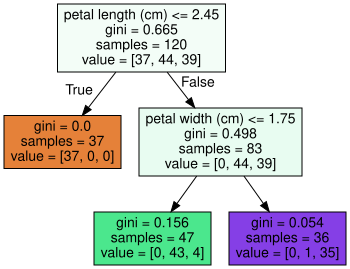

In [ ]:
# Revisamos la profundidad y el número de nodos terminales
print(f"Profundidad del árbol: {model1_Tree.get_depth()}")
print(f"Número de nodos terminales: {model1_Tree.get_n_leaves()}")
# Generamos el árbol
dot_data = export_graphviz(model1_Tree,                                 # modelo
                           feature_names = X1_train.columns,            # columnas de entrenamiento
                           filled=True)                                # colores del árbol (relleno)
Source(dot_data, format="png")

En el árbol se pueden identificar los siguientes elementos:

1. ***samples***: Número de registros del conjunto de entrenamiento a los cuales se les aplica la regla.

2. ***value***: Número de registros del conjunto de entrenamiento de cada clase en el nodo.

3. ***gini***: Mide la impureza del nodo.

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree15.png?raw=true" alt="centered image" width="650" height="350"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>


Para ilustrar el cálculo del índice de Gini consideremos el ***nodo derecho de profundidad 2.***. Gini será en este caso:

$$G_{\text{left_depth_2}}=1 - (0/83)^{2}- (44/8)^{2}- (39/83)^{2} ​​≈ 0,4981$$

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree16.png?raw=true" alt="centered image" width="650" height="300"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

Vamos a calcular probabilidades de algunos valores para *Petal.Length* y *Petal.Width*

- $(5, 1.5)$

- $(1.5, 0.4)$

- $(4, 1.5)$

- $(5.5, 2.5)$

<br>
<center><img src="https://github.com/Fabian830348/cursos/blob/master/tree/tree17.png?raw=true" alt="centered image" width="650" height="300"></center> <center><figcaption> <FONT SIZE=1 COLOR="black"> Fuente: Elaboración propia  </FONT> <figcaption></center>
<br>

In [ ]:
# Cálculo de la probabilidad de clase
model1_Tree.predict_proba([[5, 1.5], [1.5, 0.4], [4, 1.5] , [5.5, 2.5]])

array([[0.        , 0.91489362, 0.08510638],
       [1.        , 0.        , 0.        ],
       [0.        , 0.91489362, 0.08510638],
       [0.        , 0.02777778, 0.97222222]])

In [ ]:
model1_Tree.classes_

array(['setosa', 'versicolor', 'virginica'], dtype=object)

In [ ]:
# Predict tipo de Iris
model1_Tree.predict([[5, 1.5], [1.5, 0.4], [4, 1.5] , [5.5, 2.5]])

array(['versicolor', 'setosa', 'versicolor', 'virginica'], dtype=object)

Hacemos las predicciones sobre el conjunto de test

In [ ]:
# Prediccion de las clases vía el modelo DecisionTree.
y_predict = model1_Tree.predict(X1_test)

Evaluamos el modelo con la matriz de confusión.

Text(0.5, 36.72222222222221, 'Predicciones')

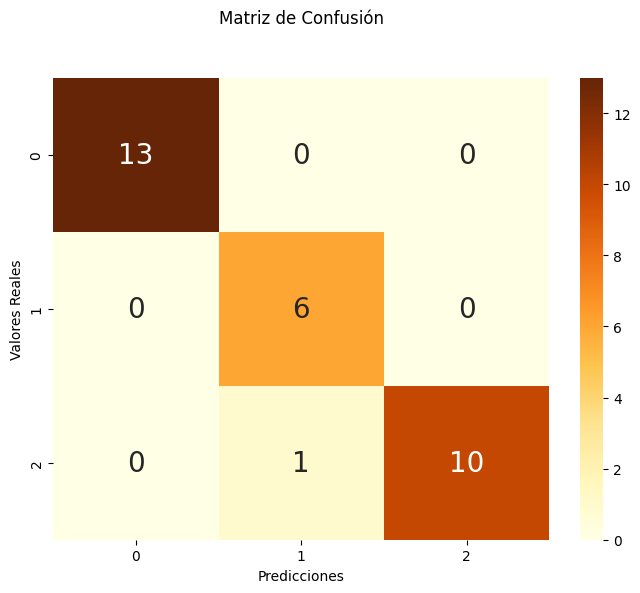

In [ ]:
from sklearn                  import metrics
from sklearn.metrics          import confusion_matrix as CM
plt.rcParams["figure.figsize"] = (8, 6)
# Matriz de Confusión
cm = CM(y1_test, y_predict)
p = sns.heatmap(pd.DataFrame(cm),                   # data.frame
                annot=True,                         # colocar números de las cajitas
                annot_kws = {'size':20},            # tamaño de la letra
                cmap="YlOrBr",                       # color de la letra
                fmt='g')                            # para que salgan los número no : notación científica
plt.title('Matriz de Confusión', y=1.1)
plt.ylabel('Valores Reales')
plt.xlabel('Predicciones')

In [ ]:
print(classification_report(y1_test,y_predict))

              precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.86      1.00      0.92         6
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



Vemos que el modelo tiene un buen rendimiento para el caso de dos variables.

## <FONT SIZE=4 COLOR="brown"> 5.2 Ejemplo con todas las variables </FONT>

Vamos a tomar todas las variables (features o características) y procedemos a aplicar el modelo

Primero, seleccionamos los conjuntos de entrenamiento y prueba. Le colocaremos un subíndice para diferenciarlos del ejemplo anterior.

reporte en train 
 
                precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        37
  versicolor       1.00      1.00      1.00        44
   virginica       1.00      1.00      1.00        39

    accuracy                           1.00       120
   macro avg       1.00      1.00      1.00       120
weighted avg       1.00      1.00      1.00       120

reporte en test 
 
                precision    recall  f1-score   support

      setosa       1.00      1.00      1.00        13
  versicolor       0.86      1.00      0.92         6
   virginica       1.00      0.91      0.95        11

    accuracy                           0.97        30
   macro avg       0.95      0.97      0.96        30
weighted avg       0.97      0.97      0.97        30



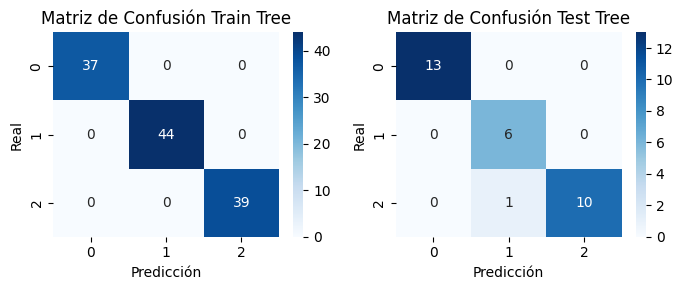

Profundidad del árbol: 6
Número de nodos terminales: 10


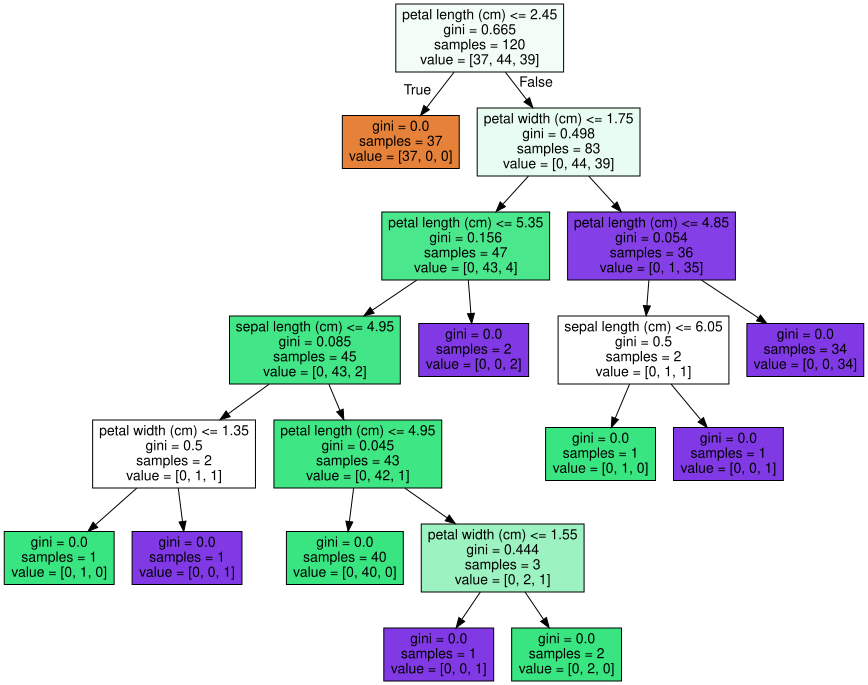

In [ ]:
# Variables
X2 = iris.drop(columns = ["species"])
y2 = iris["species"]
# conjunto de entrenamiento y prueba
X2_train, X2_test, y2_train, y2_test = train_test_split(X2,
                                                        y2,
                                                        test_size = 0.20,
                                                        random_state=123)
# Generamos el modelo
model2_Tree = DecisionTreeClassifier(random_state = 123)

## Entrenamos el modelo
model2_Tree.fit(X2_train, y2_train)

# veamos el rendimiento del modelo en el conjunto de entrenamiento
predict_class2_train = model2_Tree.predict(X2_train)
print("reporte en train \n \n ", classification_report(y2_train,predict_class2_train))

# veamos el rendimiento del modelo en el conjunto de prueba
predict_class2_test = model2_Tree.predict(X2_test)
print("reporte en test \n \n ", classification_report(y2_test,predict_class2_test))

# calculamos las matrices de confusión para train y test
cm1 = confusion_matrix(y2_train,predict_class2_train)
cm2 = confusion_matrix(y2_test,predict_class2_test)

# Crear una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Graficar la primera matriz de confusión
sns.heatmap(cm1,
            annot=True,
            annot_kws = {'size':10},
            cmap='Blues',
            fmt="g",
            ax=axes[0])
axes[0].set_title('Matriz de Confusión Train Tree')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Graficar la segunda matriz de confusión
sns.heatmap(cm2,
            annot=True,
            annot_kws = {'size':10},
            cmap='Blues',
            fmt="g",
            ax=axes[1])
axes[1].set_title('Matriz de Confusión Test Tree')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Profundidad y número de nodos
print(f"Profundidad del árbol: {model2_Tree.get_depth()}")
print(f"Número de nodos terminales: {model2_Tree.get_n_leaves()}")
# Gráfica del árbol
dot_data2 = export_graphviz(model2_Tree,                                   # modelo
                            feature_names = X2_train.columns,            # columnas de entrenamiento
                            filled=True,)                                # colores del árbol (relleno)
Source(dot_data2, format="png")

Para nuevas predicciones

In [ ]:
pred_ejemplo1 = model2_Tree.predict([[5, 7, 1, 3]])
pred_ejemplo2 = model2_Tree.predict([[11, 5, 3.2, 1.5]])
print(f" [5,7,1,3] corresponde a una flor {pred_ejemplo1}.")
print(f"[11,5,3.2,1.5] corresponde a una flor {pred_ejemplo2}.")

 [5,7,1,3] corresponde a una flor ['setosa'].
[11,5,3.2,1.5] corresponde a una flor ['versicolor'].


Es claro que podemos modificar algunos parámetros del modelo, como la profundidad, el número de nodos, etc. Y ejecutar de nuevo el modelo y evaluar su rendimiento.

- ***criterion***: cual es el criterio utilizado para la separación de instancias (gini o entropy)
- ***max_depth***: máxima profundidad del árbol en términos de niveles.
- ***min_samples_leaf***: numero mínimo de instancias para formar una hoja.
- ***class_weight***: pesos asociados a cada valor de la clase.
- ***min_samples_split***: numero mínimo de instancias para formar una hoja.
- ***max_features***: cantidad máxima de features (características) a incluir en el modelo.

En la siguiente parte vamos a ilustrar como funciona el método de la *poda* o prunnig.

Nota: revisar la curva ROC multiclase, https://programmerclick.com/article/77801955644/

## <FONT SIZE=4 COLOR="brown"> 5.3  Podado del árbol (pruning) ***ccp: cost complexity pruning*** </FONT>

El podado del árbol se usa cuando tenemos overfitting. En este caso no es necesario pero vamos a dejar el código para futuros ejercicios.



In [ ]:
from sklearn.model_selection import StratifiedKFold, cross_val_score

# 1) Comenzamos con un árbol base y ruta CCP
clf0 = DecisionTreeClassifier(random_state=123)
clf0.fit(X2_train, y2_train)

path = clf0.cost_complexity_pruning_path(X2_train,
                                         y2_train)
ccp_alphas = path.ccp_alphas[:-1]  # quitamos el último (árbol trivial)
impurities = path.impurities[:-1]

# 2) Elegimos alpha por validación cruzada (sin tocar test)
cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=123)

mean_cv_scores = []
for a in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=123, ccp_alpha=a)
    scores = cross_val_score(clf,
                             X2_train,
                             y2_train,
                             cv=cv,
                             scoring="accuracy")
    mean_cv_scores.append(scores.mean())

mean_cv_scores = np.array(mean_cv_scores)
best_alpha = ccp_alphas[np.argmax(mean_cv_scores)]

# 3) Entrenar final con best_alpha y evaluar en test
final_clf = DecisionTreeClassifier(random_state=123,
                                   ccp_alpha=best_alpha)
final_clf.fit(X2_train, y2_train)

pred_train = final_clf.predict(X2_train)
pred_test  = final_clf.predict(X2_test)

print("best_alpha:", best_alpha)
print("acc_train:", accuracy_score(y2_train, pred_train))
print("acc_test :", accuracy_score(y2_test, pred_test))
print("leaves:", final_clf.get_n_leaves(), "depth:", final_clf.get_depth())

# inspección
train_acc = []
test_acc  = []
n_leaves  = []
depths    = []

for a in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=123, ccp_alpha=a)
    clf.fit(X2_train, y2_train)
    train_acc.append(accuracy_score(y2_train, clf.predict(X2_train)))
    test_acc.append(accuracy_score(y2_test, clf.predict(X2_test)))
    n_leaves.append(clf.get_n_leaves())
    depths.append(clf.get_depth())

train_acc = np.array(train_acc)
test_acc  = np.array(test_acc)
n_leaves  = np.array(n_leaves)
depths    = np.array(depths)

best_alpha: 0.0
acc_train: 1.0
acc_test : 0.9666666666666667
leaves: 10 depth: 6


Cuando $\alpha=0$ la penalización es nula y el árbol resultante es equivalente al original.

# <FONT SIZE=5 COLOR="Purple"> 6. Ejemplo 2: conjunto de datos *cáncer* </FONT>

## <FONT SIZE=4 COLOR="green"> 6.1 Modelo con profundidad n=2 </FONT>

In [ ]:
url ="https://raw.githubusercontent.com/Fabian830348/Bases_Datos/master/cancer_clasificacion.csv"
cancer=pd.read_csv(url, sep=";")
cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,M,17.99,10.38,122.80,1001.0,1.184,2.776,3.001,1.471,...,25.38,17.33,184.60,2019.0,1.622,6.656,7.119,2.654,4.601,1.189
1,842517,M,20.57,17.77,132.90,1326.0,8.474,7.864,869.000,7.017,...,24.99,23.41,158.80,1956.0,1.238,1.866,2.416,186.000,275.000,8.902
2,84300903,M,19.69,21.25,130.00,1203.0,1.096,1.599,1.974,1.279,...,23.57,25.53,152.50,1709.0,1.444,4.245,4.504,243.000,3.613,8.758
3,84348301,M,11.42,20.38,77.58,386.1,1.425,2.839,2.414,1.052,...,14.91,26.50,98.87,567.7,2.098,8.663,6.869,2.575,6.638,173.000
4,84358402,M,20.29,14.34,135.10,1297.0,1.003,1.328,198.000,1.043,...,22.54,16.67,152.20,1575.0,1.374,205.000,0.400,1.625,2.364,7.678


In [ ]:
cancer.shape

(569, 32)

In [ ]:
cancer.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 569 entries, 0 to 568
Data columns (total 32 columns):
 #   Column                   Non-Null Count  Dtype  
---  ------                   --------------  -----  
 0   id                       569 non-null    int64  
 1   diagnosis                569 non-null    object 
 2   radius_mean              569 non-null    float64
 3   texture_mean             569 non-null    float64
 4   perimeter_mean           569 non-null    float64
 5   area_mean                569 non-null    float64
 6   smoothness_mean          569 non-null    float64
 7   compactness_mean         569 non-null    float64
 8   concavity_mean           569 non-null    float64
 9   concave points_mean      569 non-null    float64
 10  symmetry_mean            569 non-null    float64
 11  fractal_dimension_mean   569 non-null    float64
 12  radius_se                569 non-null    float64
 13  texture_se               569 non-null    float64
 14  perimeter_se             5

In [ ]:
cancer.diagnosis.value_counts()

,count
diagnosis,
B,357
M,212


In [ ]:
# etiquetar como 1 y 0 diagnosis usando replace
cancer["diagnosis"]=cancer["diagnosis"].replace({"M":1,"B":0})

In [ ]:
cancer.head()

,id,diagnosis,radius_mean,texture_mean,perimeter_mean,area_mean,smoothness_mean,compactness_mean,concavity_mean,concave points_mean,...,radius_worst,texture_worst,perimeter_worst,area_worst,smoothness_worst,compactness_worst,concavity_worst,concave points_worst,symmetry_worst,fractal_dimension_worst
0,842302,1,17.99,10.38,122.80,1001.0,1.184,2.776,3.001,1.471,...,25.38,17.33,184.60,2019.0,1.622,6.656,7.119,2.654,4.601,1.189
1,842517,1,20.57,17.77,132.90,1326.0,8.474,7.864,869.000,7.017,...,24.99,23.41,158.80,1956.0,1.238,1.866,2.416,186.000,275.000,8.902
2,84300903,1,19.69,21.25,130.00,1203.0,1.096,1.599,1.974,1.279,...,23.57,25.53,152.50,1709.0,1.444,4.245,4.504,243.000,3.613,8.758
3,84348301,1,11.42,20.38,77.58,386.1,1.425,2.839,2.414,1.052,...,14.91,26.50,98.87,567.7,2.098,8.663,6.869,2.575,6.638,173.000
4,84358402,1,20.29,14.34,135.10,1297.0,1.003,1.328,198.000,1.043,...,22.54,16.67,152.20,1575.0,1.374,205.000,0.400,1.625,2.364,7.678


In [ ]:
# Dividir en dos conjuntos
# las variables predictoras
X = cancer.iloc[:,2:]
# la variable objetivo
y = cancer.iloc[:, 1]
X_train, X_test, y_train, y_test = train_test_split(X,
                                                    y,
                                                    random_state = 0,
                                                    stratify= y,
                                                    test_size = 0.2)


Vamos a generar el modelo con entropía

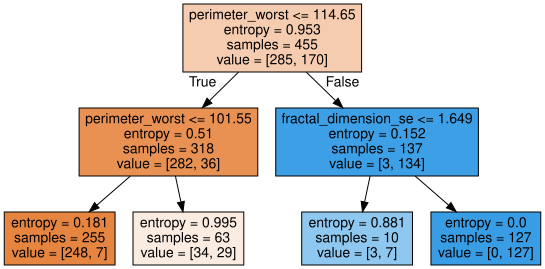

In [ ]:
#Generamos el modelo
arbol_entro= DecisionTreeClassifier(criterion="entropy",
                                    max_depth=2)
# entrenamiento del árbol
arbol_entro.fit(X_train, y_train)
# gráfica del árbol
dot_data_entro = export_graphviz(arbol_entro,
                                feature_names=X_train.columns,
                                filled=True)
Source(dot_data_entro, format="png")

Si lo hacemos por Gini

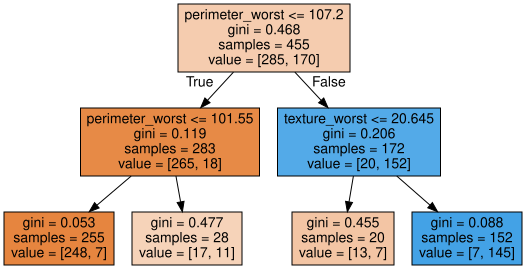

In [ ]:
## Construcción del arbol
arbol_gini=DecisionTreeClassifier(criterion="gini",
                                  max_depth=2)
arbol_gini.fit(X_train, y_train)
dot_data_gini = export_graphviz(arbol_gini,
                                feature_names=X_train.columns,
                                filled=True)
Source(dot_data_gini, format="png")

Ahora, vamos a evaluar los dos modelos

Primero con entropía

In [ ]:
y_pred_entro_test=arbol_entro.predict(X_test)
y_pred_entro_train=arbol_entro.predict(X_train)
# en los datos de entrenamiento
print(confusion_matrix(y_train, y_pred_entro_train))
# en los datos de prueba
print(confusion_matrix(y_test, y_pred_entro_test))

[[282   3]
 [ 36 134]]
[[70  2]
 [ 6 36]]


In [ ]:
print("resultados para train entropia\n", classification_report(y_train,y_pred_entro_train))
print("resultados para test entropia \n" ,classification_report(y_test,y_pred_entro_test))

resultados para train entropia
               precision    recall  f1-score   support

           0       0.89      0.99      0.94       285
           1       0.98      0.79      0.87       170

    accuracy                           0.91       455
   macro avg       0.93      0.89      0.90       455
weighted avg       0.92      0.91      0.91       455

resultados para test entropia 
               precision    recall  f1-score   support

           0       0.92      0.97      0.95        72
           1       0.95      0.86      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.91      0.92       114
weighted avg       0.93      0.93      0.93       114



**Ejercicio:** Hacerlo con gini y comparar.

In [ ]:
y_pred_gini_test=arbol_gini.predict(X_test)
y_pred_gini_train=arbol_gini.predict(X_train)
# en los datos de entrenamiento
print(confusion_matrix(y_train, y_pred_gini_train))
# en los datos de prueba
print(confusion_matrix(y_test, y_pred_gini_test))

[[278   7]
 [ 25 145]]
[[69  3]
 [ 5 37]]


In [ ]:
print("resultados para train gini \n", classification_report(y_train,y_pred_gini_train))
print("resultados para test gini  \n" ,classification_report(y_test,y_pred_gini_test))

resultados para train gini 
               precision    recall  f1-score   support

           0       0.92      0.98      0.95       285
           1       0.95      0.85      0.90       170

    accuracy                           0.93       455
   macro avg       0.94      0.91      0.92       455
weighted avg       0.93      0.93      0.93       455

resultados para test gini  
               precision    recall  f1-score   support

           0       0.93      0.96      0.95        72
           1       0.93      0.88      0.90        42

    accuracy                           0.93       114
   macro avg       0.93      0.92      0.92       114
weighted avg       0.93      0.93      0.93       114



## <FONT SIZE=4 COLOR="green"> 6.2 Optimizar hiperparámetros </FONT>

Ahora, vamos a hacer búsqueda en grilla

- **criterion**: mide la calidad de la división (gini suele ser más rápido, entropy más informativo, log_loss es más reciente en scikit-learn ≥ 1.1).

- **max_depth**: controla la complejidad del árbol (None = crece hasta que no pueda más).

- **min_samples_split**: evita sobreajuste si lo subes.

- **min_samples_leaf**: asegura que cada hoja tenga un número mínimo de observaciones.

- **max_features**: reduce el número de variables candidatas por división (útil en ensambles).

- **splitter**: best elige la mejor división, random añade aleatoriedad (a veces útil).

In [ ]:
# Modelo
modelo_tree=DecisionTreeClassifier()

# definimos los parámetros que vamos a combinar. Diccionario
grid_params = {
    "criterion": ["gini", "entropy"],               # función de impureza
    "max_depth": [None] + list(range(2, 21, 2)),    # profundidad máxima
    "min_samples_split": [2, 5, 10, 20],            # mínimo de muestras para dividir
    "min_samples_leaf": [1, 2, 5, 10],              # mínimo de muestras en una hoja
    "max_features": [None, "sqrt", "log2"],         # nº de features consideradas en cada split
}

# hacemos la búsqueda en grilla con 5-folds
grid_tree = GridSearchCV(modelo_tree,                             # el modelo aplicado
                         grid_params,                             # los parámetros que van a variar
                         cv = 10,                                 # el número de folds
                         scoring = "accuracy",                    # la métrica de evaluación
                         verbose = 1)                             # para que imprima resultados. Posibilidades: 1,2 o 3

# Entrenar el modelo obtenido arriba
modelo_tree_grid = grid_tree.fit(X_train,y_train)

Fitting 10 folds for each of 1056 candidates, totalling 10560 fits


In [ ]:
print("Mejor score: ",modelo_tree_grid.best_score_)
print("Mejores hiperparámetros", modelo_tree_grid.best_params_)
modelo_tree_best = modelo_tree_grid.best_estimator_
modelo_tree_best

Mejor score:  0.9428985507246377
Mejores hiperparámetros {'criterion': 'gini', 'max_depth': 10, 'max_features': 'sqrt', 'min_samples_leaf': 5, 'min_samples_split': 2}


DecisionTreeClassifier(max_depth=10, max_features='sqrt', min_samples_leaf=5)

Ahora, usamos ese mejor modelo

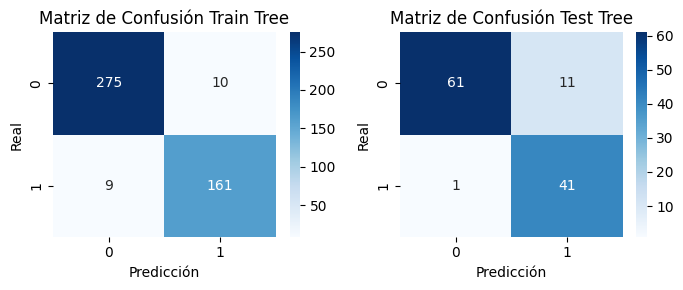

,Tree_train,Tree_test
accuracy,0.958242,0.894737
recall,0.947059,0.976190
specificity,0.964912,0.847222
precision,0.941520,0.788462
f1,0.944282,0.872340


In [ ]:
# veamos el rendimiento del modelo en el conjunto de entrenamiento
y_pred_train = modelo_tree_best.predict(X_train)

# veamos el rendimiento del modelo en el conjunto de test
y_pred_test = modelo_tree_best.predict(X_test)


# calculamos las matrices de confusión para train y test
cm1 = confusion_matrix(y_train,y_pred_train)
cm2 = confusion_matrix(y_test,y_pred_test)

# Crear una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Graficar la primera matriz de confusión
sns.heatmap(cm1,
            annot=True,
            annot_kws = {'size':10},
            cmap='Blues',
            fmt="g",
            ax=axes[0])
axes[0].set_title('Matriz de Confusión Train Tree')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Graficar la segunda matriz de confusión
sns.heatmap(cm2,
            annot=True,
            annot_kws = {'size':10},
            cmap='Blues',
            fmt="g",
            ax=axes[1])
axes[1].set_title('Matriz de Confusión Test Tree')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# metricas en train
metrics=["accuracy", "recall" , "specificity", "precision", "f1"]
# valores
values_train = [accuracy_score(y_train,y_pred_train),
          recall_score(y_train,y_pred_train),
          specificity_score(y_train,y_pred_train),
          precision_score(y_train,y_pred_train),
          f1_score(y_train,y_pred_train)]
values_test = [accuracy_score(y_test,y_pred_test),
          recall_score(y_test,y_pred_test),
          specificity_score(y_test,y_pred_test),
          precision_score(y_test,y_pred_test),
          f1_score(y_test,y_pred_test)]

df = pd.DataFrame({"Tree_train" : values_train,
                      "Tree_test" : values_test}, index = metrics)
df

## <FONT SIZE=4 COLOR="green"> 6.3 Selección de características </FONT>



Podemos ver cuál es la importancia de las variables para el modelo de clasificación usando RandomForest

In [ ]:
modelo_tree_best.feature_importances_

array([0.01431045, 0.        , 0.        , 0.        , 0.        ,
       0.00407997, 0.00153738, 0.        , 0.        , 0.00780516,
       0.00207353, 0.        , 0.        , 0.        , 0.        ,
       0.        , 0.        , 0.00124173, 0.00106434, 0.02270592,
       0.        , 0.11087977, 0.78338694, 0.00464439, 0.        ,
       0.00585387, 0.        , 0.01321874, 0.        , 0.0271978 ])

In [ ]:
print("Importancia de los predictores en el modelo")
print("-------------------------------------------")
importancia_predictores = pd.DataFrame(
    {'predictor': X_train.columns.tolist(),
     'importancia': modelo_tree_best.feature_importances_}
)
importancia_predictores.sort_values('importancia', ascending=False)

Importancia de los predictores en el modelo
-------------------------------------------


,predictor,importancia
22,perimeter_worst,0.783387
21,texture_worst,0.110880
29,fractal_dimension_worst,0.027198
19,fractal_dimension_se,0.022706
0,radius_mean,0.014310
27,concave points_worst,0.013219
9,fractal_dimension_mean,0.007805
25,compactness_worst,0.005854
23,area_worst,0.004644
5,compactness_mean,0.004080


# <FONT SIZE=4 COLOR="green"> 7. Ejemplo 3: Con la base Carseats </FONT>

El set de datos `Carseats`, accesible en Python a través de `statsmodels.datasets.get_rdataset`, contiene información sobre:

- La venta de sillas de seguridad infantiles en 400 tiendas distintas.
- Para cada una de las 400 tiendas se han registrado 11 variables.

**objetivo:** Generar un modelo de clasificación que permita predecir si una tienda tiene ventas altas `(Sales > 8)` o `bajas (Sales <= 8)` en función de todas las variables disponibles.

In [ ]:
carseats = sm.datasets.get_rdataset("Carseats", "ISLR")
datos = carseats.data
print(carseats.__doc__)

.. container::

   .. container::

      ======== ===============
      Carseats R Documentation
      ======== ===============

      .. rubric:: Sales of Child Car Seats
         :name: sales-of-child-car-seats

      .. rubric:: Description
         :name: description

      A simulated data set containing sales of child car seats at 400
      different stores.

      .. rubric:: Usage
         :name: usage

      .. code:: R

         Carseats

      .. rubric:: Format
         :name: format

      A data frame with 400 observations on the following 11 variables.

      ``Sales``
         Unit sales (in thousands) at each location

      ``CompPrice``
         Price charged by competitor at each location

      ``Income``
         Community income level (in thousands of dollars)

      ``Advertising``
         Local advertising budget for company at each location (in
         thousands of dollars)

      ``Population``
         Population size in region (in thousands)

      ``Pric

In [ ]:
datos.head(5)

,Sales,CompPrice,Income,Advertising,Population,Price,ShelveLoc,Age,Education,Urban,US
0,9.50,138,73,11,276,120,Bad,42,17,Yes,Yes
1,11.22,111,48,16,260,83,Good,65,10,Yes,Yes
2,10.06,113,35,10,269,80,Medium,59,12,Yes,Yes
3,7.40,117,100,4,466,97,Medium,55,14,Yes,Yes
4,4.15,141,64,3,340,128,Bad,38,13,Yes,No


# <FONT SIZE=4 COLOR="green"> 8. Ejercicio en Clase </FONT>

Considere el siguiente conjunto de datos, que se trabajó en el caso de estudio 1.

- En la url
```python
https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_credito.csv
```
encontrará los datos ya limpios, es decir, con el proceso de limpieza que realizaron en el trabajo.

- Aplique el modelo de árboles de decisión

  1. **Prepruning**: Optimice hiperparámetros (no incluya el ccp) y evalúe el rendimiento del árbol
  2. **post-pruning**: Busque el mejor valor del cost complexity pruning (ccp) y evalué el rendimiento del árbol
  3. Incluya el ccp en la optimización de hiperparámetros (punto 1) y evalúe el modelo

- Compare las métricas (accuracy) en test de 1-2-3 y concluya.

- Con el mejor modelo, analice la importancia de los predictores.


In [ ]:
credito= pd.read_csv("https://raw.githubusercontent.com/Fabian830348/Bases_Datos/refs/heads/master/datos_credito.csv")

In [ ]:
credito.describe()

,card,reports,age,income,share,expenditure,owner,selfemp,dependents,months,majorcards,active
count,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000,1310.000000
mean,0.775573,0.458779,33.374873,3.368444,0.068644,184.996730,0.440458,0.069466,0.993130,55.111450,0.817557,6.993130
std,0.417364,1.349327,9.886538,1.698234,0.094828,272.843418,0.496632,0.254341,1.248051,66.229211,0.386356,6.302954
min,0.000000,0.000000,18.166670,0.210000,0.000109,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000
25%,1.000000,0.000000,25.416670,2.240625,0.002272,4.583333,0.000000,0.000000,0.000000,12.000000,1.000000,2.000000
50%,1.000000,0.000000,31.250000,2.900000,0.038775,101.231650,0.000000,0.000000,0.500000,30.000000,1.000000,6.000000
75%,1.000000,0.000000,39.416670,4.000000,0.093396,248.859150,1.000000,0.000000,2.000000,72.000000,1.000000,11.000000
max,1.000000,14.000000,83.500000,13.500000,0.906320,3099.505000,1.000000,1.000000,6.000000,540.000000,1.000000,46.000000


In [ ]:
# diagrama de dispersión
px.scatter(credito,
           x = "age",
           y = "months",
           color="card")

reporte en train 
 
                precision    recall  f1-score   support

           0       1.00      1.00      1.00       228
           1       1.00      1.00      1.00       820

    accuracy                           1.00      1048
   macro avg       1.00      1.00      1.00      1048
weighted avg       1.00      1.00      1.00      1048

reporte en test 
 
                precision    recall  f1-score   support

           0       0.94      0.92      0.93        66
           1       0.97      0.98      0.98       196

    accuracy                           0.97       262
   macro avg       0.96      0.95      0.95       262
weighted avg       0.97      0.97      0.97       262



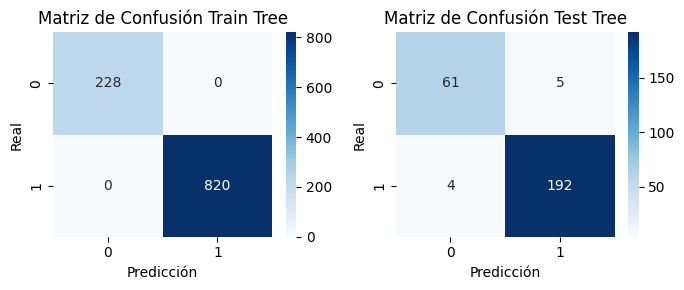

Profundidad del árbol: 11
Número de nodos terminales: 29


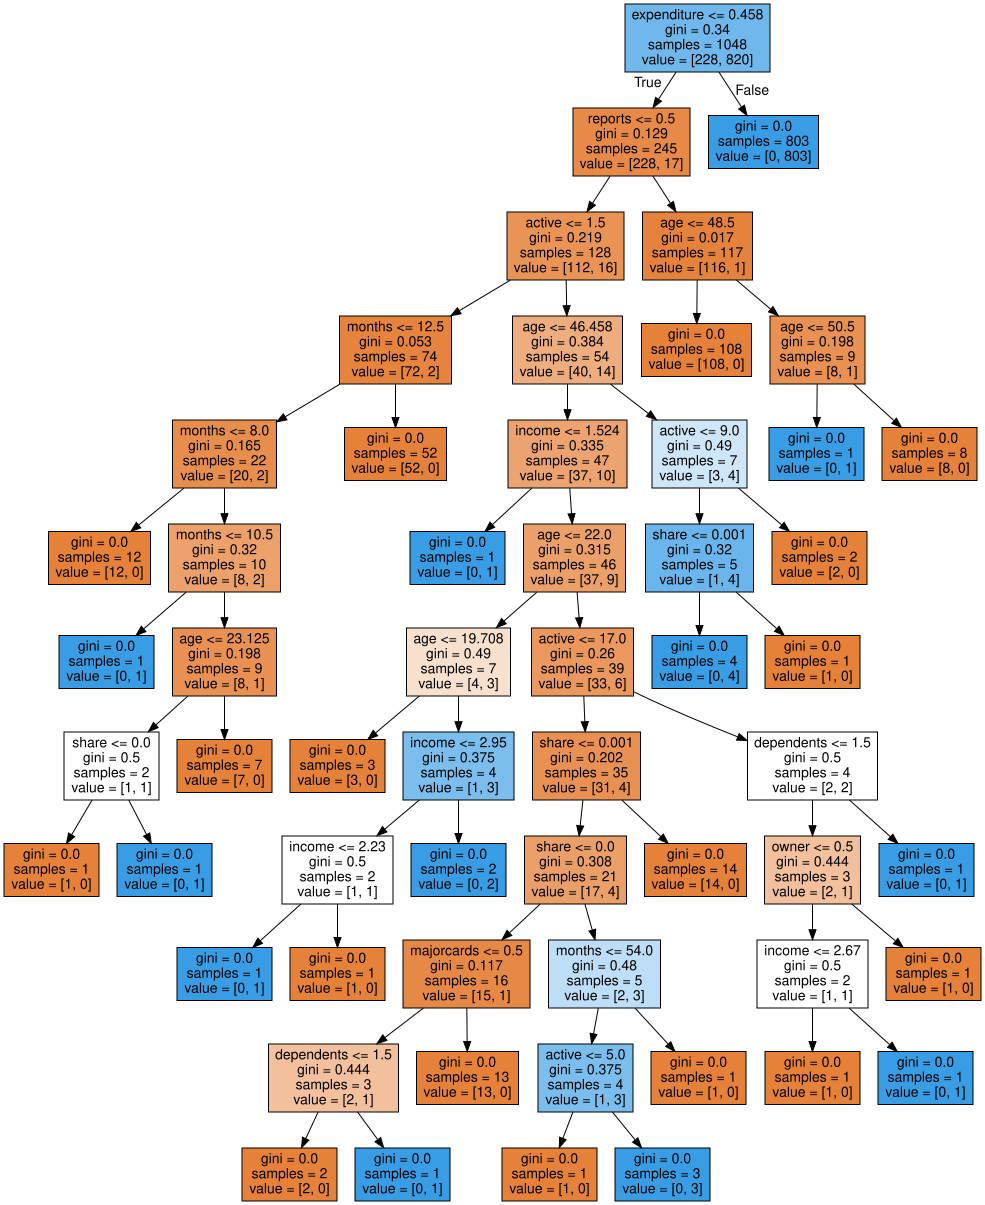

In [ ]:
# Variables
X3 = credito.drop(columns = ["card"])
y3 = credito["card"]
# conjunto de entrenamiento y prueba
X3_train, X3_test, y3_train, y3_test = train_test_split(X3,
                                                        y3,
                                                        test_size = 0.20,

                                                        random_state=123)
# Generamos el modelo
model3_Tree = DecisionTreeClassifier(random_state = 123)      # Semilla
## Entrenamos el modelo
model3_Tree.fit(X3_train, y3_train)

# veamos el rendimiento del modelo en el conjunto de entrenamiento
predict_class3_train = model3_Tree.predict(X3_train)
print("reporte en train \n \n ", classification_report(y3_train,predict_class3_train))

# veamos el rendimiento del modelo en el conjunto de prueba
predict_class3_test = model3_Tree.predict(X3_test)
print("reporte en test \n \n ", classification_report(y3_test,predict_class3_test))

# calculamos las matrices de confusión para train y test
cm1 = confusion_matrix(y3_train,predict_class3_train)
cm2 = confusion_matrix(y3_test,predict_class3_test)

# Crear una figura con dos subgráficos
fig, axes = plt.subplots(1, 2, figsize=(7, 3))

# Graficar la primera matriz de confusión
sns.heatmap(cm1,
            annot=True,
            annot_kws = {'size':10},
            cmap='Blues',
            fmt="g",
            ax=axes[0])
axes[0].set_title('Matriz de Confusión Train Tree')
axes[0].set_xlabel('Predicción')
axes[0].set_ylabel('Real')

# Graficar la segunda matriz de confusión
sns.heatmap(cm2,
            annot=True,
            annot_kws = {'size':10},
            cmap='Blues',
            fmt="g",
            ax=axes[1])
axes[1].set_title('Matriz de Confusión Test Tree')
axes[1].set_xlabel('Predicción')
axes[1].set_ylabel('Real')

# Mostrar el gráfico
plt.tight_layout()
plt.show()

# Profundidad y número de nodos
print(f"Profundidad del árbol: {model3_Tree.get_depth()}")
print(f"Número de nodos terminales: {model3_Tree.get_n_leaves()}")
# Gráfica del árbol
dot_data3 = export_graphviz(model3_Tree,                                   # modelo
                            feature_names = X3_train.columns,            # columnas de entrenamiento
                            filled=True,)                                # colores del árbol (relleno)
Source(dot_data3, format="png")

In [ ]:
# Modelo
modelo_tree=DecisionTreeClassifier(random_state=123)

# definimos los parámetros que vamos a combinar. Diccionario
# Reducimos el número de opciones para acelerar la búsqueda
grid_params = {
    "criterion": ["gini", "entropy"],               # función de impureza
    "max_depth": [None, 5, 10],                     # profundidad máxima reducida
    "min_samples_split": [2, 10],                   # mínimo de muestras para dividir reducido
    "min_samples_leaf": [1, 5],                     # mínimo de muestras en una hoja reducido
    "max_features": [None, "sqrt"],               # nº de features consideradas en cada split reducido
}

# hacemos la búsqueda en grilla con 5-folds
grid_tree = GridSearchCV(modelo_tree,                             # el modelo aplicado
                         grid_params,                             # los parámetros que van a variar
                         cv = 10,                                 # el número de folds
                         scoring = "accuracy",                    # la métrica de evaluación
                         verbose = 1)                             # para que imprima resultados. Posibilidades: 1,2 o 3

# Entrenar el modelo obtenido arriba
modelo_tree_grid = grid_tree.fit(X3_train,y3_train)

Fitting 10 folds for each of 48 candidates, totalling 480 fits


In [ ]:
print("Mejor score: ",modelo_tree_grid.best_score_)
print("Mejores hiperparámetros", modelo_tree_grid.best_params_)
modelo_tree_best = modelo_tree_grid.best_estimator_
modelo_tree_best

Mejor score:  0.9809065934065935
Mejores hiperparámetros {'criterion': 'entropy', 'max_depth': 5, 'max_features': None, 'min_samples_leaf': 1, 'min_samples_split': 10}


DecisionTreeClassifier(criterion='entropy', max_depth=5, min_samples_split=10,
                       random_state=123)

In [ ]:
# 1) Comenzamos con un árbol base y ruta CCP
clf0 = DecisionTreeClassifier(random_state=123)
clf0.fit(X3_train, y3_train)

path = clf0.cost_complexity_pruning_path(X3_train,
                                         y3_train)
ccp_alphas = path.ccp_alphas[:-1]  # quitamos el último (árbol trivial)
impurities = path.impurities[:-1]

# 2) Elegimos alpha por validación cruzada (sin tocar test)
cv = StratifiedKFold(n_splits=5,
                     shuffle=True,
                     random_state=123)

mean_cv_scores = []
for a in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=123, ccp_alpha=a)
    scores = cross_val_score(clf,
                             X3_train,
                             y3_train,
                             cv=cv,
                             scoring="accuracy")
    mean_cv_scores.append(scores.mean())

mean_cv_scores = np.array(mean_cv_scores)
best_alpha = ccp_alphas[np.argmax(mean_cv_scores)]

# 3) Entrenar final con best_alpha y evaluar en test
final_clf = DecisionTreeClassifier(random_state=123,
                                   ccp_alpha=best_alpha)
final_clf.fit(X3_train, y3_train)

pred_train = final_clf.predict(X3_train)
pred_test  = final_clf.predict(X3_test)

print("best_alpha:", best_alpha)
print("acc_train:", accuracy_score(y3_train, pred_train))
print("acc_test :", accuracy_score(y3_test, pred_test))
print("leaves:", final_clf.get_n_leaves(), "depth:", final_clf.get_depth())

# inspección
train_acc = []
test_acc  = []
n_leaves  = []
depths    = []

for a in ccp_alphas:
    clf = DecisionTreeClassifier(random_state=123, ccp_alpha=a)
    clf.fit(X3_train, y3_train)
    train_acc.append(accuracy_score(y3_train, clf.predict(X3_train)))
    test_acc.append(accuracy_score(y3_test, clf.predict(X3_test)))
    n_leaves.append(clf.get_n_leaves())
    depths.append(clf.get_depth())

train_acc = np.array(train_acc)
test_acc  = np.array(test_acc)
n_leaves  = np.array(n_leaves)
depths    = np.array(depths)

best_alpha: 0.0023975561598244197
acc_train: 0.9837786259541985
acc_test : 0.9809160305343512
leaves: 2 depth: 1


In [ ]:
# Modelo
modelo_tree3=DecisionTreeClassifier(random_state=123)

# definimos los parámetros que vamos a combinar. Diccionario
# Reducimos el número de opciones para acelerar la búsqueda
grid_params = {
    "criterion": ["gini", "entropy"],               # función de impureza
    "max_depth": [None, 5, 10],                     # profundidad máxima reducida
    "ccp_alpha": ccp_alphas
}

# hacemos la búsqueda en grilla con 5-folds
grid_tree3 = GridSearchCV(modelo_tree,                             # el modelo aplicado
                         grid_params,                             # los parámetros que van a variar
                         cv = 10,                                 # el número de folds
                         scoring = "accuracy",                    # la métrica de evaluación
                         verbose = 1)                             # para que imprima resultados. Posibilidades: 1,2 o 3

# Entrenar el modelo obtenido arriba
modelo_tree_grid3 = grid_tree3.fit(X3_train,y3_train)

Fitting 10 folds for each of 72 candidates, totalling 720 fits


In [ ]:
print("Mejor score: ",modelo_tree_grid.best_score_)
print("Mejores hiperparámetros", modelo_tree_grid.best_params_)
modelo_tree_best = modelo_tree_grid.best_estimator_
modelo_tree_best

Mejor score:  0.9809065934065935
Mejores hiperparámetros {'ccp_alpha': np.float64(0.0023975561598244197), 'criterion': 'gini', 'max_depth': None}


DecisionTreeClassifier(ccp_alpha=np.float64(0.0023975561598244197),
                       random_state=123)

In [ ]:
print("Importancia de los predictores en el árbol sin podar (credito)")
print("-----------------------------------------------------------")
importancia_predictores_unpruned = pd.DataFrame(
    {'predictor': X3_train.columns.tolist(),
     'importancia': model3_Tree.feature_importances_}
)
importancia_predictores_unpruned.sort_values('importancia', ascending=False)

Importancia de los predictores en el árbol sin podar (credito)
-----------------------------------------------------------


,predictor,importancia
4,expenditure,0.911319
10,active,0.021761
1,age,0.020047
3,share,0.015165
2,income,0.010556
8,months,0.008448
7,dependents,0.005605
0,reports,0.004647
9,majorcards,0.001518
5,owner,0.000934
